# Publication figures: 9-method × 92-clone × 2-space benchmark

Visualization suite for `figures/klein_per_clone_w2_all.csv`, organized from high-agreement headline figures (Tier 1) to less-confident exploratory views (Tier 3).

**Tier 1 — Headline + supporting**
- 1A: Aggregated heatmap (fate / multipotency / clone-size blocks, rank-encoded)
- 1B: Performance-profile CDF (Dolan–Moré)
- 1C: Critical-difference diagram (Demšar)

**Tier 2 — Supplement**
- 2A: Full-resolution 9 × 92 heatmap with annotation bars
- 2B: Replicate-stability view

**Tier 3 — Exploratory**
- 3A: Condition-profile PCA on the 9-method score vector
- 3B: W2 vs clone size small multiples (conditional on 3A)

## Setup

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, LogNorm, Normalize
from matplotlib.patches import Patch, Rectangle
from scipy.stats import friedmanchisquare, rankdata, spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path('../../figures/klein_per_clone_w2_all.csv')
FIG_DIR = Path('../../figures')
FIG_DIR.mkdir(exist_ok=True)

def setup_style():
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 13,
        'axes.titlesize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
        'legend.fontsize': 10,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })
    sns.set_style('ticks')

setup_style()

def save_fig(fig, name):
    for ext in ('pdf', 'png'):
        fig.savefig(FIG_DIR / f'{name}.{ext}')
    print(f'  saved {FIG_DIR}/{name}.{{pdf,png}}')

In [2]:
df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
print('methods:', sorted(df['method'].unique()))
print('spaces:', sorted(df['space'].unique()))
print('n clones:', df['clone'].nunique())
df.head(3)

shape: (1646, 16)
methods: ['DeepRUOT', 'MIOFlow', 'OTCFM', 'PRESCIENT', 'SF2M', 'TIGON', 'TrajectoryNet', 'pdp+', 'scDiffEq']
spaces: ['dm10', 'pc30']
n clones: 92


,method,space,clone,w2_raw_mean,w2_raw_std,w2_scaled_mean,n_runs,clone_size_src,clone_size_tgt,clone_size_d6,dominant_fate,multipotency,pseudotime_spread,clone_size_d4,initial_var_dm,initial_var_pc
0,DeepRUOT,dm10,Clone_1099,0.010157,0.000344,0.010157,4,9,47,47,Neutrophil,1,0.053959,9,0.297773,3.337828
1,DeepRUOT,dm10,Clone_123,0.006198,0.000747,0.006198,4,5,20,20,Monocyte,2,0.157227,5,0.037467,6.415137
2,DeepRUOT,dm10,Clone_1258,0.006871,0.000235,0.006871,4,3,22,22,Mast,2,0.099004,3,20.624729,26.133310


In [3]:
# Method palette (mirrors scripts/benchmarking/4.vis_benchmark.ipynb but with the
# method names actually present in the CSV — 'pdp+' not 'pseudodynamics+', 'DeepRUOT' not 'DeepRUOTv2').
METHOD_COLORS = {
    'OTCFM':         '#505175',
    'SF2M':          '#7C8DBE',
    'pdp+':          '#C5D9ED',
    'PRESCIENT':     '#FFE7BD',
    'TrajectoryNet': '#EFB397',
    'MIOFlow':       '#D087A3',
    'TIGON':         '#A1689E',
    'scDiffEq':      '#88B5A3',
    'DeepRUOT':      '#D4856E',
}

# Method order: best → worst by global median w2_raw_mean across all clones & spaces.
_method_medians = df.groupby('method')['w2_raw_mean'].median().sort_values()
METHOD_ORDER = _method_medians.index.tolist()
print('global method order (best → worst):')
for m in METHOD_ORDER:
    print(f'  {m:<14s}  median W2 = {_method_medians[m]:.4f}')

# Per-space method order (used when ranking within a space).
METHOD_ORDER_BY_SPACE = {
    s: df.query('space == @s').groupby('method')['w2_raw_mean'].median().sort_values().index.tolist()
    for s in ['dm10', 'pc30']
}

# Fate palette (7 categories present in the data).
FATE_PALETTE = {
    'Neutrophil': '#1f77b4',
    'Monocyte':   '#ff7f0e',
    'Mast':       '#2ca02c',
    'Meg':        '#d62728',
    'Baso':       '#9467bd',
    'Erythroid':  '#8c564b',
    'undiff':     '#D3D3D3',
}

SPACES = ['dm10', 'pc30']
SPACE_TITLE = {'dm10': 'DM10', 'pc30': 'PC30'}

global method order (best → worst):
  scDiffEq        median W2 = 2.1742
  pdp+            median W2 = 2.5532
  TIGON           median W2 = 2.6359
  TrajectoryNet   median W2 = 2.6625
  DeepRUOT        median W2 = 2.6830
  OTCFM           median W2 = 3.3889
  MIOFlow         median W2 = 3.5554
  SF2M            median W2 = 3.6089
  PRESCIENT       median W2 = 3.6749


In [4]:
def add_label_columns(d):
    """Add categorical label columns used for aggregation: potency, size_bin."""
    d = d.copy()
    d['potency'] = pd.Categorical(
        np.where(d['multipotency'] == 0, 'undiff',
                 np.where(d['multipotency'] == 1, 'unipotent', 'multipotent')),
        categories=['undiff', 'unipotent', 'multipotent'], ordered=True,
    )
    # Tertile boundaries computed on unique clones (one row per clone) so the bins
    # reflect clone-size distribution, not row-count distribution.
    clone_sizes = d.drop_duplicates('clone').set_index('clone')['clone_size_d6']
    q33, q67 = clone_sizes.quantile([0.33, 0.67])
    d['size_bin'] = pd.Categorical(
        np.where(d['clone_size_d6'] <= q33, f'small (≤{int(q33)})',
                 np.where(d['clone_size_d6'] <= q67, f'medium (≤{int(q67)})',
                          f'large (>{int(q67)})')),
        categories=[f'small (≤{int(q33)})', f'medium (≤{int(q67)})', f'large (>{int(q67)})'],
        ordered=True,
    )
    return d

df = add_label_columns(df)
print('potency counts:')
print(df.drop_duplicates('clone')['potency'].value_counts())
print('size_bin counts:')
print(df.drop_duplicates('clone')['size_bin'].value_counts())
print('dominant_fate counts:')
print(df.drop_duplicates('clone')['dominant_fate'].value_counts())

potency counts:
potency
multipotent    45
unipotent      35
undiff         12
Name: count, dtype: int64
size_bin counts:
size_bin
small (≤19)     31
medium (≤26)    31
large (>26)     30
Name: count, dtype: int64
dominant_fate counts:
dominant_fate
Monocyte      36
Baso          18
Neutrophil    13
undiff        12
Mast           6
Meg            5
Erythroid      2
Name: count, dtype: int64


## Tier 1A — Aggregated heatmap (THE main figure)

Rows = 9 methods (ordered best→worst). Columns = aggregated condition groups in three blocks: dominant fate, potency, clone-size tertile. Cell color = rank within column (1 = best, 9 = worst), diverging palette with midpoint at rank 5. Cell text = raw mean W2.

Two side-by-side panels (DM10 | PC30).

  saved ../../figures/per_clone_w2_aggregated_heatmap.{pdf,png}


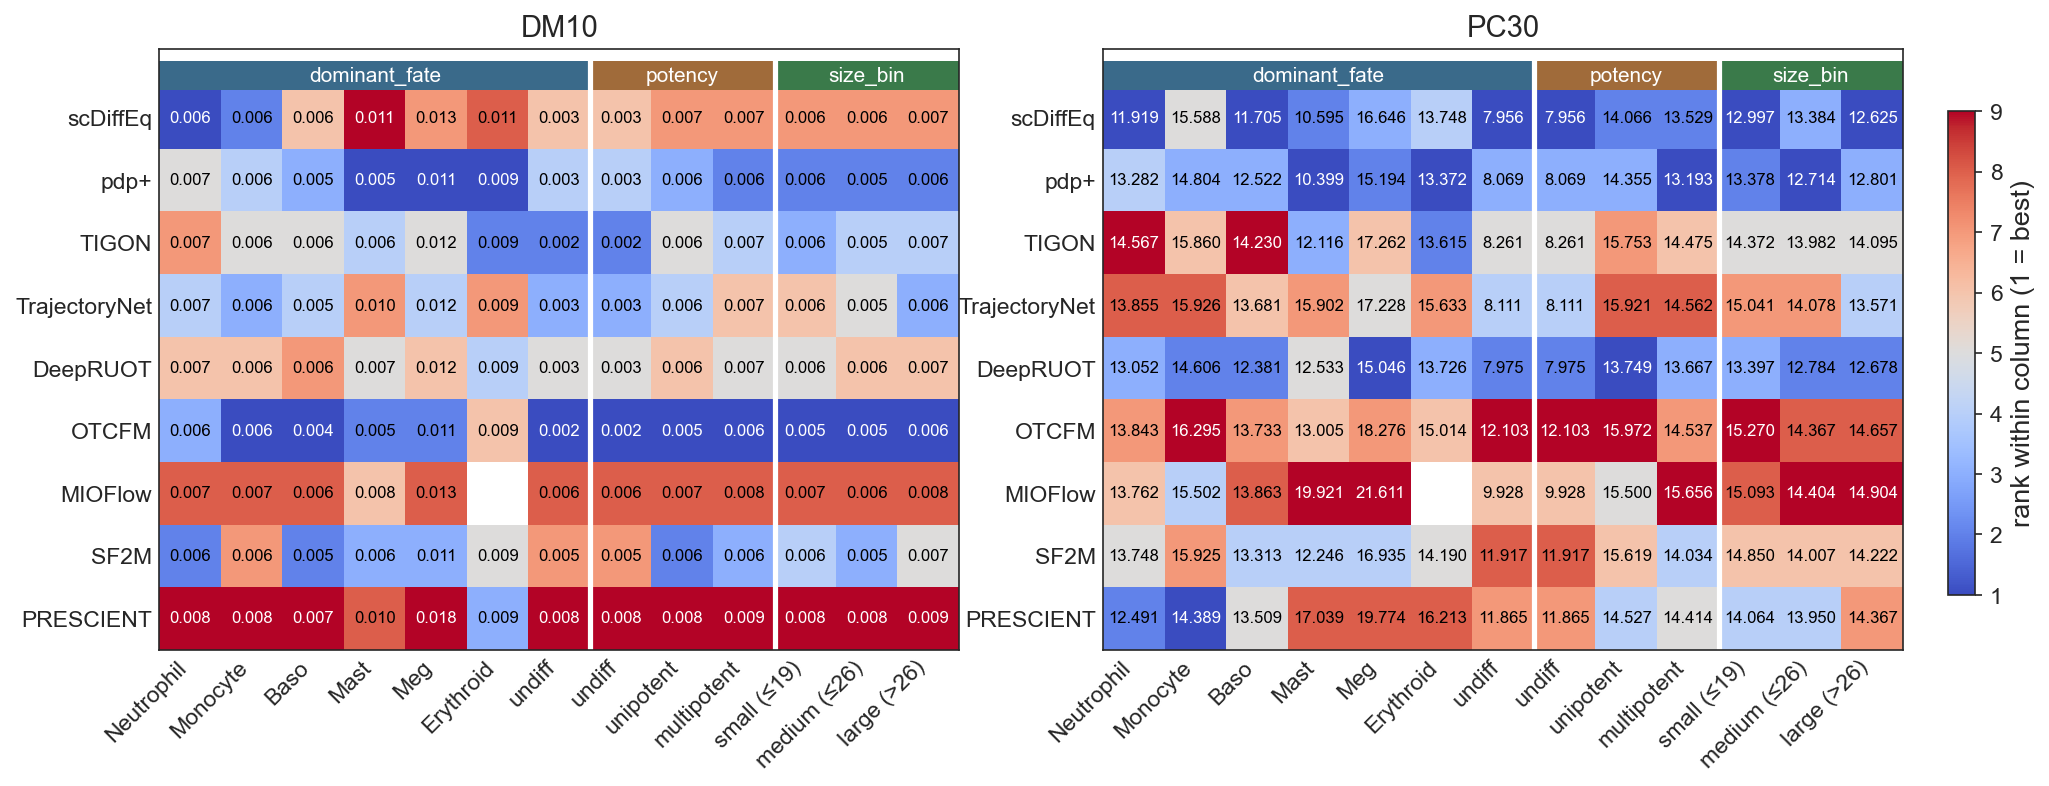

In [5]:
FATE_ORDER = ['Neutrophil', 'Monocyte', 'Baso', 'Mast', 'Meg', 'Erythroid', 'undiff']
POTENCY_ORDER = ['undiff', 'unipotent', 'multipotent']

def build_aggregated_matrix(d_space, method_order):
    """Return a (methods x grouped-columns) DataFrame of mean w2_raw_mean per group."""
    size_order = list(d_space['size_bin'].cat.categories)
    blocks = {
        'dominant_fate': [f for f in FATE_ORDER if f in d_space['dominant_fate'].unique()],
        'potency':       POTENCY_ORDER,
        'size_bin':      size_order,
    }
    pieces = []
    column_keys = []
    for col, levels in blocks.items():
        agg = d_space.groupby(['method', col], observed=True)['w2_raw_mean'].mean().unstack(col)
        agg = agg.reindex(index=method_order, columns=levels)
        pieces.append(agg)
        column_keys += [(col, lv) for lv in levels]
    mat = pd.concat(pieces, axis=1)
    mat.columns = pd.MultiIndex.from_tuples(column_keys, names=['block', 'group'])
    return mat

def plot_aggregated_heatmap(
    df, save_name='per_clone_w2_aggregated_heatmap',
    cmap='coolwarm', annot_fmt='{:.3f}', figsize=(15, 5.2),
):
    fig, axes = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={'wspace': 0.18},
    )
    n_methods = len(METHOD_ORDER)
    rank_norm = Normalize(vmin=1, vmax=n_methods)
    block_colors = {'dominant_fate': '#3a6a8a', 'potency': '#a06b3a', 'size_bin': '#3a7a4a'}

    for ax, space in zip(axes, SPACES):
        d_space = df.query('space == @space')
        mat = build_aggregated_matrix(d_space, METHOD_ORDER)
        rank_mat = mat.rank(axis=0, method='average', ascending=True)  # 1 = lowest W2 = best

        im = ax.imshow(rank_mat.values, aspect='auto', cmap=cmap, norm=rank_norm)
        ax.set_xticks(range(mat.shape[1]))
        ax.set_xticklabels([g for _, g in mat.columns], rotation=45, ha='right')
        ax.set_yticks(range(n_methods))
        ax.set_yticklabels(METHOD_ORDER)
        ax.set_title(SPACE_TITLE[space])
        ax.tick_params(axis='both', length=0)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.values[i, j]
                if np.isnan(v):
                    txt = '—'
                else:
                    txt = annot_fmt.format(v)
                # Text color: dark on light cells (mid ranks), light on extremes
                rgba = mpl.colormaps[cmap](rank_norm(rank_mat.values[i, j]))
                lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=8, color='white' if lum < 0.45 else 'black')

        # Block delimiters & top annotation bar.
        block_changes = [0]
        prev = mat.columns.get_level_values('block')[0]
        for k, (b, _) in enumerate(mat.columns):
            if b != prev:
                block_changes.append(k)
                prev = b
        block_changes.append(mat.shape[1])
        for k in block_changes[1:-1]:
            ax.axvline(k - 0.5, color='white', linewidth=2.5)
        # Annotation strip above
        for start, end in zip(block_changes[:-1], block_changes[1:]):
            block_name = mat.columns.get_level_values('block')[start]
            ax.add_patch(Rectangle(
                (start - 0.5, -0.9), end - start, 0.45,
                facecolor=block_colors[block_name], clip_on=False, edgecolor='none',
            ))
            ax.text((start + end - 1) / 2, -0.67, block_name,
                    ha='center', va='center', color='white', fontsize=10, clip_on=False)
        ax.set_ylim(n_methods - 0.5, -1.1)  # leave room for the strip

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.18, 0.012, 0.62])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('rank within column (1 = best)')
    cbar.set_ticks(range(1, n_methods + 1))

    save_fig(fig, save_name)
    return fig

_ = plot_aggregated_heatmap(df)
plt.show()

## Tier 1B — Performance-profile CDFs (Dolan–Moré)

For each clone, the *best* W2 across methods is the reference. Each curve shows the fraction of clones where a method's W2 ≤ τ × best. Curve climbing fastest near τ=1 = most-often-best; right-tail height = worst-case competitiveness.

  saved ../../figures/per_clone_w2_performance_profile.{pdf,png}


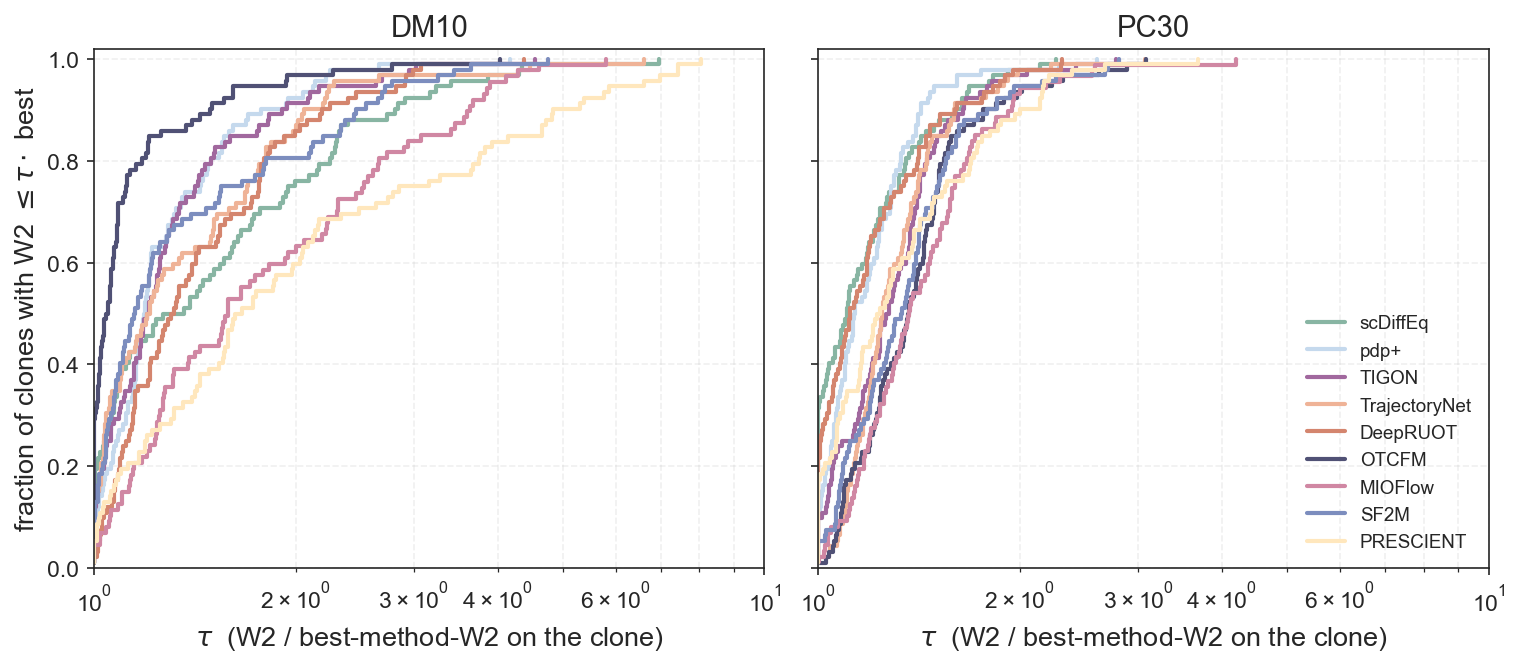

In [6]:
def plot_performance_profile(df, save_name='per_clone_w2_performance_profile',
                              cmap=None, tau_max=10.0, figsize=(12, 4.5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True,
                              gridspec_kw={'wspace': 0.08})
    palette = cmap if isinstance(cmap, dict) else METHOD_COLORS
    for ax, space in zip(axes, SPACES):
        d = df.query('space == @space')
        wide = d.pivot_table(index='clone', columns='method', values='w2_raw_mean', aggfunc='mean')
        wide = wide.reindex(columns=METHOD_ORDER)
        best = wide.min(axis=1)
        tau = wide.div(best, axis=0)  # ratio to best per clone (≥1)
        tau = tau.replace([np.inf, -np.inf], np.nan)
        for m in METHOD_ORDER:
            vals = tau[m].dropna().values
            if len(vals) == 0:
                continue
            xs = np.sort(vals)
            ys = np.arange(1, len(xs) + 1) / len(xs)
            # Step curve, capped at tau_max for plotting
            xs_plot = np.clip(xs, 1.0, tau_max)
            ax.step(xs_plot, ys, where='post', linewidth=2.0, color=palette.get(m, 'k'), label=m)
        ax.set_xscale('log')
        ax.set_xlim(1.0, tau_max)
        ax.set_ylim(0, 1.02)
        ax.set_xlabel(r'$\tau$  (W2 / best-method-W2 on the clone)')
        if ax is axes[0]:
            ax.set_ylabel(r'fraction of clones with W2 $\leq \tau \cdot$ best')
        ax.set_title(SPACE_TITLE[space])
        ax.grid(True, which='both', linestyle='--', alpha=0.3)
    axes[-1].legend(loc='lower right', frameon=False, fontsize=9)
    save_fig(fig, save_name)
    return fig

_ = plot_performance_profile(df)
plt.show()

## Tier 1C — Critical-difference diagram (Demšar)

Friedman test on per-clone ranks → Nemenyi post-hoc → group methods whose mean ranks differ by less than the critical difference (q_{α=0.05} · √(k(k+1)/(6N))).

  saved ../../figures/per_clone_w2_critical_difference.{pdf,png}


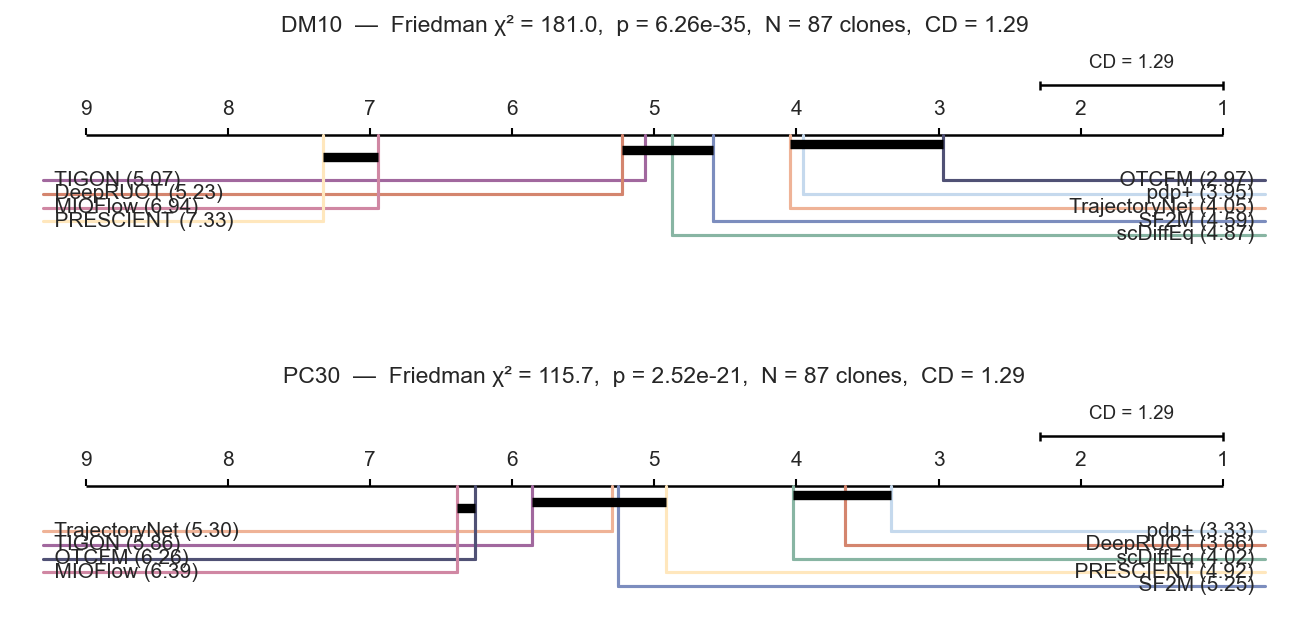

In [7]:
# Studentized-range upper-quantile q_{α=0.05} for Nemenyi (two-tailed), from Demšar (2006) Table 5.
_NEMENYI_Q_005 = {
    2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949,
    8: 3.031, 9: 3.102, 10: 3.164, 11: 3.219, 12: 3.268,
}

def compute_ranks(df, space):
    d = df.query('space == @space')
    wide = d.pivot_table(index='clone', columns='method', values='w2_raw_mean', aggfunc='mean')
    wide = wide.reindex(columns=METHOD_ORDER).dropna(axis=0, how='any')
    ranks = wide.apply(lambda row: rankdata(row.values, method='average'), axis=1, result_type='expand')
    ranks.columns = wide.columns
    return wide, ranks

def critical_difference(k, n, alpha=0.05):
    q = _NEMENYI_Q_005[k] if alpha == 0.05 else None
    return q * np.sqrt(k * (k + 1) / (6 * n))

def plot_critical_difference(df, save_name='per_clone_w2_critical_difference',
                              cmap=None, figsize=(11, 5.0)):
    palette = cmap if isinstance(cmap, dict) else METHOD_COLORS
    fig, axes = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'hspace': 0.55})
    for ax, space in zip(axes, SPACES):
        wide, ranks = compute_ranks(df, space)
        n = len(ranks)
        k = ranks.shape[1]
        mean_ranks = ranks.mean(axis=0).sort_values()
        stat, p = friedmanchisquare(*[wide[c].values for c in wide.columns])
        cd = critical_difference(k, n)

        ax.set_xlim(0.5, k + 0.5)
        ax.set_ylim(-1.5, 1.0)
        ax.invert_xaxis()
        ax.axis('off')
        # Top axis line + ticks
        ax.hlines(0, 1, k, color='black', linewidth=1.2)
        for tick in range(1, k + 1):
            ax.vlines(tick, 0, 0.08, color='black', linewidth=1.0)
            ax.text(tick, 0.18, str(tick), ha='center', va='bottom', fontsize=10)
        ax.set_title(
            f'{SPACE_TITLE[space]}  —  Friedman χ² = {stat:.1f},  p = {p:.2e},  N = {n} clones,  CD = {cd:.2f}',
            loc='center', fontsize=11,
        )

        # Draw method labels: best (lowest rank) on the LEFT (inverted axis)
        half = (k + 1) // 2
        for idx, (method, r) in enumerate(mean_ranks.items()):
            side = 'left' if idx < half else 'right'
            y_label = -0.55 - 0.15 * (idx % half)
            x_label = 0.7 if side == 'left' else (k + 0.3)
            ax.plot([r, r], [0, y_label + 0.05], color=palette.get(method, 'k'), linewidth=1.5)
            ax.plot([r, x_label], [y_label + 0.05, y_label + 0.05],
                    color=palette.get(method, 'k'), linewidth=1.5)
            ax.text(x_label, y_label + 0.05, f'  {method} ({r:.2f})  ',
                    ha='right' if side == 'left' else 'left', va='center', fontsize=10)

        # CD bars: connect adjacent groups whose rank difference < CD
        sorted_methods = mean_ranks.index.tolist()
        sorted_ranks = mean_ranks.values
        groups = []
        i = 0
        while i < len(sorted_ranks):
            j = i
            while j + 1 < len(sorted_ranks) and (sorted_ranks[j + 1] - sorted_ranks[i]) < cd:
                j += 1
            if j > i:
                groups.append((sorted_ranks[i], sorted_ranks[j]))
            i = j + 1
        for g_idx, (a, b) in enumerate(groups):
            y_bar = -0.10 - 0.07 * g_idx
            ax.hlines(y_bar, a, b, color='black', linewidth=4.5)

        # CD scale marker bottom-left
        ax.hlines(0.55, 1, 1 + cd, color='black', linewidth=1.2)
        ax.vlines([1, 1 + cd], 0.50, 0.60, color='black', linewidth=1.2)
        ax.text(1 + cd / 2, 0.70, f'CD = {cd:.2f}', ha='center', va='bottom', fontsize=9)

    save_fig(fig, save_name)
    return fig

_ = plot_critical_difference(df)
plt.show()

## Tier 2A — Full-resolution 9 × 92 heatmap (supplement)

Two stacked panels (DM10 top, PC30 bottom). Columns are 92 clones, sorted hierarchically by dominant_fate → multipotency → clone_size_d6. Three annotation strips above each panel show the categorical labels. Cell color = raw `w2_raw_mean` on a sequential palette (no cell text — too dense).

  saved ../../figures/per_clone_w2_full_heatmap.{pdf,png}


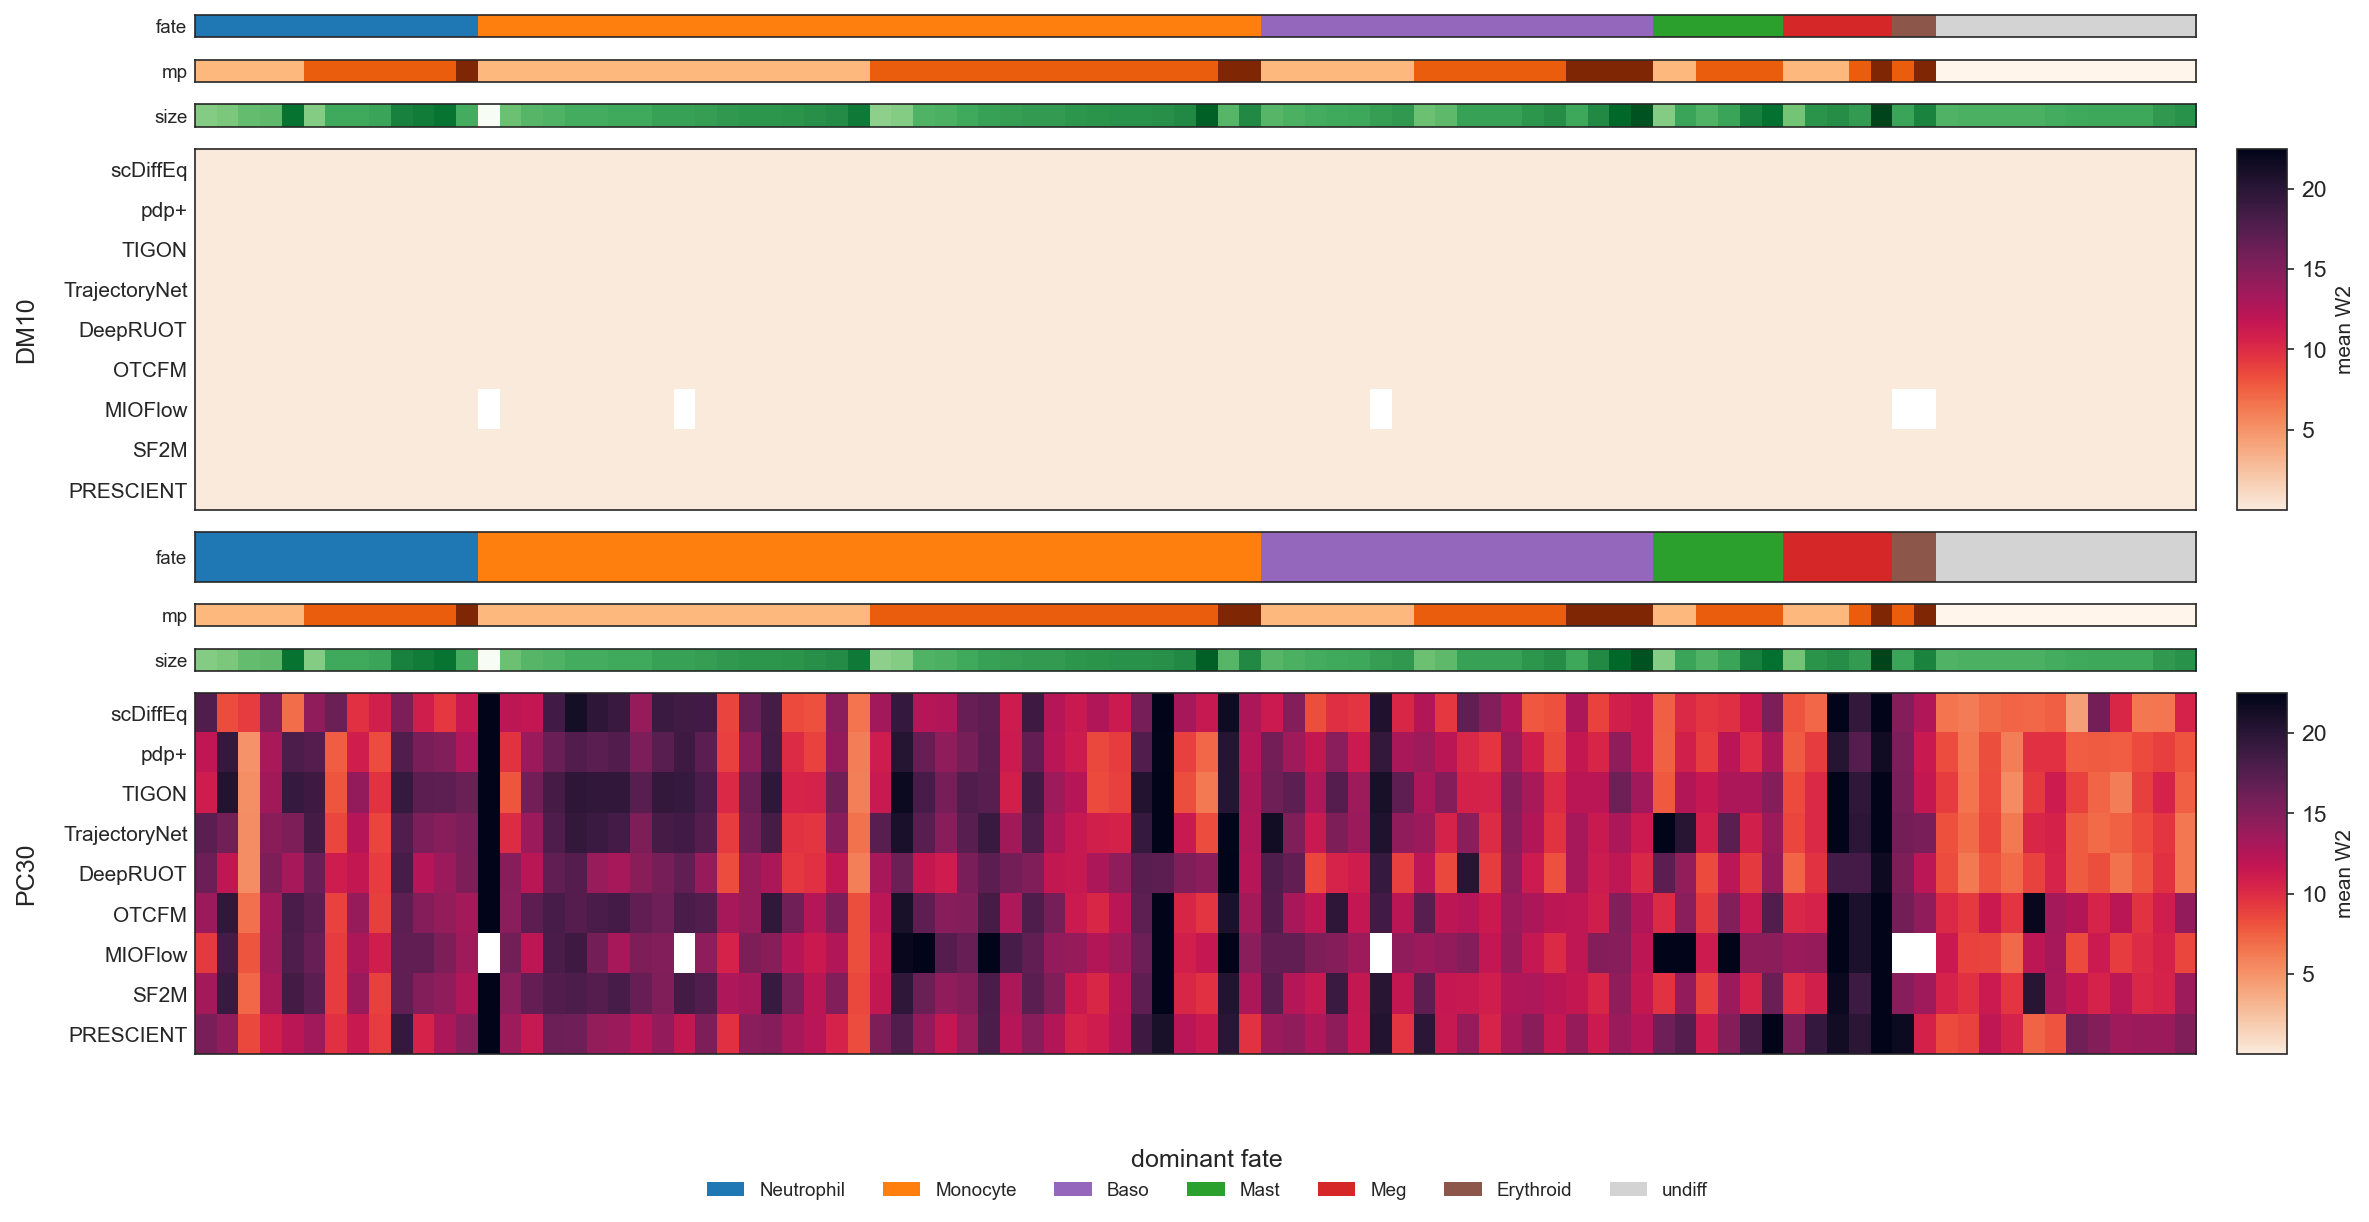

In [8]:
def plot_full_heatmap(df, save_name='per_clone_w2_full_heatmap',
                      cmap='rocket_r', figsize=(18, 9)):
    # Use a clone order common to both spaces (sort using union of clones across spaces).
    clone_props = (
        df.drop_duplicates('clone')[['clone', 'dominant_fate', 'multipotency', 'clone_size_d6']]
          .assign(fate_idx=lambda x: x['dominant_fate'].map({f: i for i, f in enumerate(FATE_ORDER)}))
          .sort_values(['fate_idx', 'multipotency', 'clone_size_d6'])
    )
    clone_order = clone_props['clone'].tolist()

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=8, ncols=2, height_ratios=[0.25, 0.25, 0.25, 4, 0.55, 0.25, 0.25, 4],
        width_ratios=[40, 1], wspace=0.04, hspace=0.20,
    )
    # Build per-space sub-grid: rows for fate strip, potency strip, size strip, heatmap
    # Top space = dm10 (rows 0–3), bottom = pc30 (rows 4–7) — row 4 is a spacer.
    vmin = df['w2_raw_mean'].min()
    vmax = df['w2_raw_mean'].quantile(0.98)  # clip extreme outliers in color scale

    for s_idx, space in enumerate(SPACES):
        base_row = 0 if s_idx == 0 else 4
        # Annotation strips
        ax_fate = fig.add_subplot(gs[base_row, 0])
        ax_pot  = fig.add_subplot(gs[base_row + 1, 0])
        ax_sz   = fig.add_subplot(gs[base_row + 2, 0])
        ax_hm   = fig.add_subplot(gs[base_row + 3, 0])
        ax_cb   = fig.add_subplot(gs[base_row + 3, 1])

        d = df.query('space == @space')
        mat = d.pivot_table(index='method', columns='clone', values='w2_raw_mean', aggfunc='mean')
        mat = mat.reindex(index=METHOD_ORDER, columns=clone_order)

        im = ax_hm.imshow(mat.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        ax_hm.set_yticks(range(len(METHOD_ORDER)))
        ax_hm.set_yticklabels(METHOD_ORDER, fontsize=10)
        ax_hm.set_xticks([])
        ax_hm.set_ylabel(f'{SPACE_TITLE[space]}', fontsize=12, rotation=90, labelpad=12)
        ax_hm.tick_params(axis='y', length=0)

        # Fate strip
        fate_arr = clone_props.set_index('clone').loc[clone_order, 'dominant_fate']
        fate_colors = np.array([mpl.colors.to_rgb(FATE_PALETTE[f]) for f in fate_arr])
        ax_fate.imshow(fate_colors.reshape(1, -1, 3), aspect='auto')
        ax_fate.set_yticks([0])
        ax_fate.set_yticklabels(['fate'], fontsize=9)
        ax_fate.set_xticks([])
        ax_fate.tick_params(axis='y', length=0)

        # Potency strip
        pot_arr = clone_props.set_index('clone').loc[clone_order, 'multipotency'].values.astype(float)
        ax_pot.imshow(pot_arr.reshape(1, -1), aspect='auto', cmap='Oranges', vmin=0, vmax=3)
        ax_pot.set_yticks([0])
        ax_pot.set_yticklabels(['mp'], fontsize=9)
        ax_pot.set_xticks([])
        ax_pot.tick_params(axis='y', length=0)

        # Size strip (log)
        sz_arr = clone_props.set_index('clone').loc[clone_order, 'clone_size_d6'].values.astype(float)
        ax_sz.imshow(np.log1p(sz_arr).reshape(1, -1), aspect='auto', cmap='Greens')
        ax_sz.set_yticks([0])
        ax_sz.set_yticklabels(['size'], fontsize=9)
        ax_sz.set_xticks([])
        ax_sz.tick_params(axis='y', length=0)

        cbar = fig.colorbar(im, cax=ax_cb)
        cbar.set_label('mean W2', fontsize=10)

    # Fate legend below the figure
    fate_handles = [Patch(facecolor=FATE_PALETTE[f], edgecolor='none', label=f) for f in FATE_ORDER if f in df['dominant_fate'].unique()]
    fig.legend(handles=fate_handles, loc='lower center', ncol=len(fate_handles),
                bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=9, title='dominant fate')

    save_fig(fig, save_name)
    return fig

_ = plot_full_heatmap(df)
plt.show()

## Tier 2B — Replicate-stability view

Left: per-method bar plot of *median* `w2_raw_std` across 92 clones, error bars = IQR of `w2_raw_std` across clones. Right: scatter of `w2_raw_mean` vs `w2_raw_std` per (method, clone) point. Methods with `n_runs == 1` (no std defined) are dropped from this view with a note.

  dropped (n_runs=1, no std): ['pdp+']


  saved ../../figures/per_clone_w2_replicate_stability.{pdf,png}


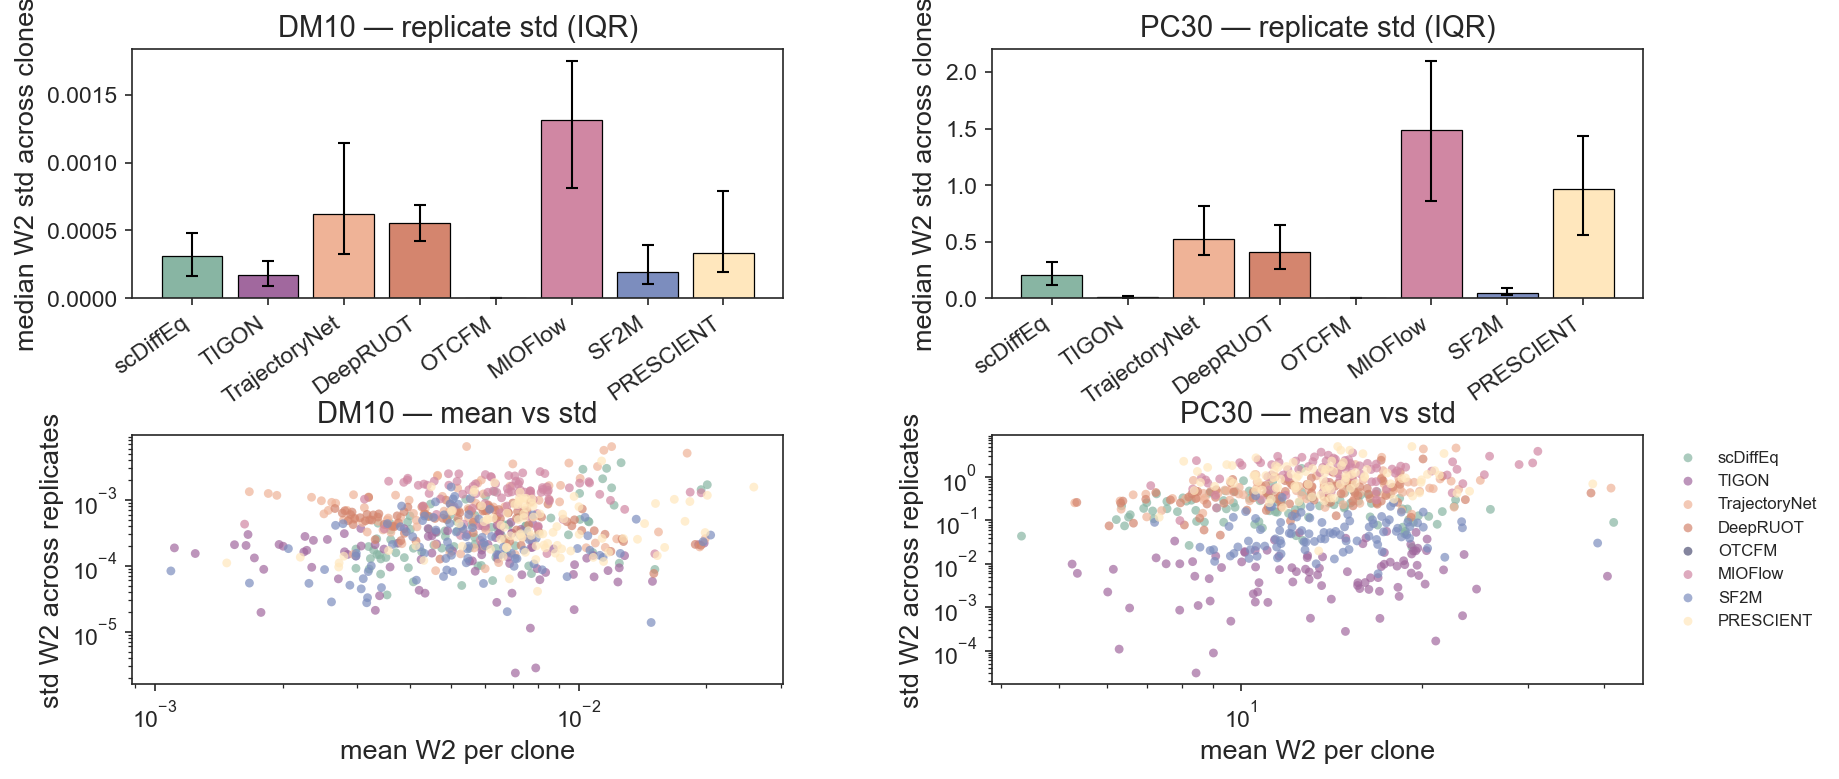

In [9]:
def plot_replicate_stability(df, save_name='per_clone_w2_replicate_stability',
                              cmap=None, figsize=(13, 5.5)):
    palette = cmap if isinstance(cmap, dict) else METHOD_COLORS
    has_std = df[df['n_runs'] >= 2].copy()
    dropped = sorted(set(df['method']) - set(has_std['method']))
    if dropped:
        print(f'  dropped (n_runs=1, no std): {dropped}')
    methods_shown = [m for m in METHOD_ORDER if m in has_std['method'].unique()]

    fig, axes = plt.subplots(2, 2, figsize=figsize, gridspec_kw={'wspace': 0.32, 'hspace': 0.55})
    for col, space in enumerate(SPACES):
        d = has_std.query('space == @space')

        # Bar plot: median std with IQR whiskers
        ax_bar = axes[0, col]
        stats = (d.groupby('method')['w2_raw_std']
                    .agg(median='median', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
                    .reindex(methods_shown))
        x = np.arange(len(methods_shown))
        bar_colors = [palette.get(m, 'gray') for m in methods_shown]
        ax_bar.bar(x, stats['median'].values, color=bar_colors, edgecolor='black', linewidth=0.6)
        ax_bar.errorbar(
            x, stats['median'].values,
            yerr=[stats['median'].values - stats['q25'].values,
                  stats['q75'].values - stats['median'].values],
            fmt='none', ecolor='black', capsize=3, linewidth=1.0,
        )
        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(methods_shown, rotation=35, ha='right')
        ax_bar.set_ylabel('median W2 std across clones')
        ax_bar.set_title(f'{SPACE_TITLE[space]} — replicate std (IQR)')

        # Scatter: mean vs std
        ax_sc = axes[1, col]
        for m in methods_shown:
            sub = d.query('method == @m')
            ax_sc.scatter(sub['w2_raw_mean'], sub['w2_raw_std'],
                          color=palette.get(m, 'gray'), s=18, alpha=0.7, label=m, edgecolor='none')
        ax_sc.set_xscale('log')
        ax_sc.set_yscale('log')
        ax_sc.set_xlabel('mean W2 per clone')
        ax_sc.set_ylabel('std W2 across replicates')
        ax_sc.set_title(f'{SPACE_TITLE[space]} — mean vs std')
        if col == len(SPACES) - 1:
            ax_sc.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)

    save_fig(fig, save_name)
    return fig

_ = plot_replicate_stability(df)
plt.show()

## Tier 3A — Condition-profile PCA on the 9-method score vector

For each clone in each space, build a 9-D vector of `w2_raw_mean` (one entry per method). Z-score per method (across clones) and run PCA. Scatter PC1/PC2 of the 92 clones, colored by `dominant_fate`, sized by `clone_size_d6`, marker shape by potency.

Use the resulting PC1/PC2 → look at which biological axis (fate, potency, clone size) separates clones in *method-relative-performance* space. If PC1 cleanly separates by clone size → consider Tier 3B; otherwise the three-block Tier 1A is the right aggregation choice.

  saved ../../figures/per_clone_w2_profile_pca.{pdf,png}
  PC1 vs clone size correlation: {'dm10': (0.04977722602771783, 0.647053248130645), 'pc30': (-0.004077408838993929, 0.9701010039666677)}


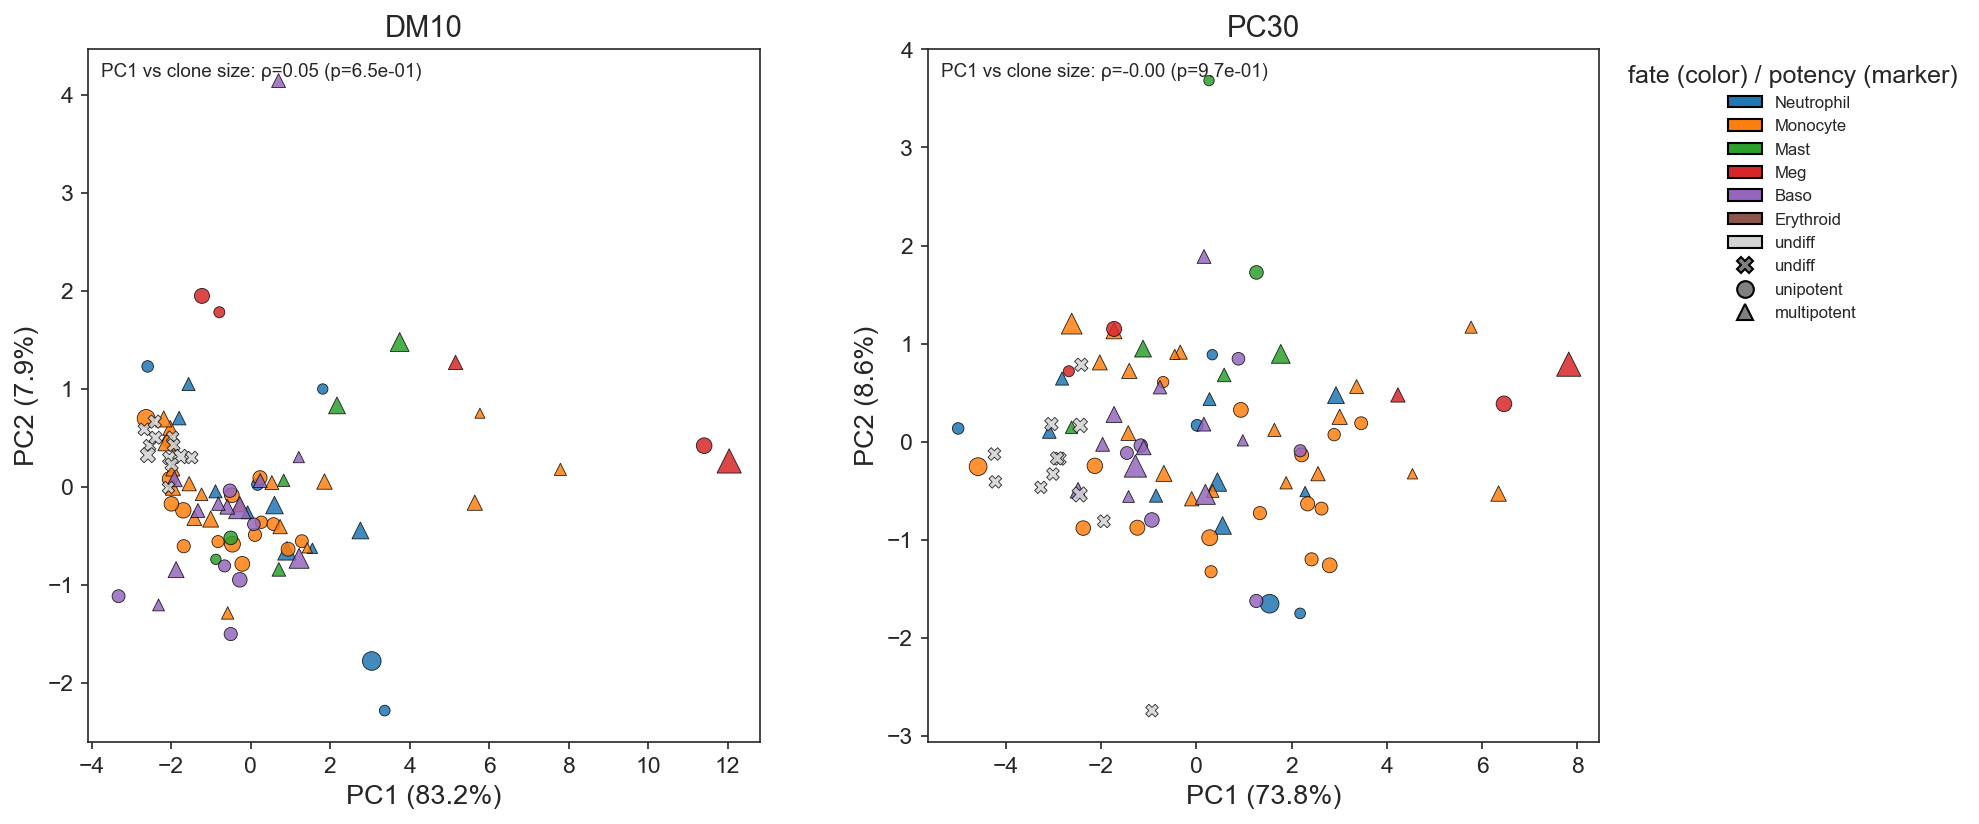

In [10]:
def plot_condition_profile_pca(df, save_name='per_clone_w2_profile_pca',
                                cmap=None, figsize=(13, 6)):
    palette = cmap if isinstance(cmap, dict) else FATE_PALETTE
    marker_for_potency = {'undiff': 'X', 'unipotent': 'o', 'multipotent': '^'}
    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'wspace': 0.25})
    pc1_size_corr = {}
    for ax, space in zip(axes, SPACES):
        d = df.query('space == @space')
        wide = d.pivot_table(index='clone', columns='method', values='w2_raw_mean', aggfunc='mean')
        wide = wide.reindex(columns=METHOD_ORDER).dropna(axis=0, how='any')
        clones = wide.index
        X = StandardScaler().fit_transform(wide.values)
        pca = PCA(n_components=2)
        Y = pca.fit_transform(X)
        props = d.drop_duplicates('clone').set_index('clone').loc[clones]
        for fate, color in palette.items():
            for pot, marker in marker_for_potency.items():
                mask = (props['dominant_fate'] == fate) & (props['potency'] == pot)
                if mask.sum() == 0:
                    continue
                ax.scatter(
                    Y[mask.values, 0], Y[mask.values, 1],
                    s=10 + 1.5 * props.loc[mask, 'clone_size_d6'].values,
                    color=color, marker=marker, edgecolor='black', linewidth=0.4, alpha=0.85,
                )
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        ax.set_title(SPACE_TITLE[space])
        rho, p = spearmanr(Y[:, 0], props['clone_size_d6'].values)
        pc1_size_corr[space] = (rho, p)
        ax.text(0.02, 0.98, f'PC1 vs clone size: ρ={rho:.2f} (p={p:.1e})',
                transform=ax.transAxes, va='top', fontsize=9)

    # Legends
    fate_handles = [Patch(facecolor=palette[f], edgecolor='black', label=f) for f in palette]
    pot_handles = [plt.Line2D([0], [0], marker=marker_for_potency[p], color='w',
                                  markerfacecolor='gray', markeredgecolor='black', label=p, markersize=8)
                     for p in ['undiff', 'unipotent', 'multipotent']]
    axes[-1].legend(handles=fate_handles + pot_handles, loc='upper left',
                     bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8,
                     title='fate (color) / potency (marker)')
    save_fig(fig, save_name)
    print('  PC1 vs clone size correlation:', pc1_size_corr)
    return fig, pc1_size_corr

_, pc1_size_corr = plot_condition_profile_pca(df)
plt.show()

## Tier 3B — W2 vs clone size small multiples

Only built if 3A flags clone size as a dominant axis (|Spearman ρ(PC1, clone size)| ≥ 0.4 in at least one space).

9 panels per space, one per method: scatter of `clone_size_d6` (log) vs `w2_raw_mean`, points colored by `dominant_fate`, optional Spearman ρ annotation.

In [11]:
def plot_w2_vs_clone_size(df, save_name='per_clone_w2_vs_clone_size',
                            cmap=None, figsize=(15, 9)):
    palette = cmap if isinstance(cmap, dict) else FATE_PALETTE
    fig, axes = plt.subplots(
        2, len(METHOD_ORDER), figsize=figsize,
        gridspec_kw={'wspace': 0.25, 'hspace': 0.5}, sharey='row',
    )
    for row, space in enumerate(SPACES):
        d = df.query('space == @space')
        for col, method in enumerate(METHOD_ORDER):
            ax = axes[row, col]
            sub = d.query('method == @method')
            for fate, color in palette.items():
                m = sub['dominant_fate'] == fate
                if m.sum() == 0:
                    continue
                ax.scatter(sub.loc[m, 'clone_size_d6'], sub.loc[m, 'w2_raw_mean'],
                            color=color, s=18, alpha=0.8, edgecolor='none', label=fate)
            ax.set_xscale('log')
            if len(sub) >= 5:
                rho, p = spearmanr(sub['clone_size_d6'], sub['w2_raw_mean'])
                ax.text(0.05, 0.95, f'ρ={rho:.2f}', transform=ax.transAxes,
                            va='top', fontsize=9)
            if row == 0:
                ax.set_title(method, fontsize=10)
            if col == 0:
                ax.set_ylabel(f'{SPACE_TITLE[space]}\nmean W2', fontsize=10)
            if row == len(SPACES) - 1:
                ax.set_xlabel('clone size d6', fontsize=9)

    fate_handles = [Patch(facecolor=palette[f], edgecolor='none', label=f) for f in palette]
    fig.legend(handles=fate_handles, loc='lower center', ncol=len(fate_handles),
                bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=9, title='dominant fate')
    save_fig(fig, save_name)
    return fig

# Decision gate: only build if Tier 3A's PC1 correlates strongly with clone size in at least one space.
max_abs_rho = max(abs(rho) for rho, _ in pc1_size_corr.values())
if max_abs_rho >= 0.4:
    print(f'Tier 3A PC1 strongly tied to clone size (max |ρ| = {max_abs_rho:.2f}). Building Tier 3B.')
    _ = plot_w2_vs_clone_size(df)
    plt.show()
else:
    print(f'Tier 3A PC1 not strongly tied to clone size (max |ρ| = {max_abs_rho:.2f}). Skipping Tier 3B.')
    print('  (Re-run plot_w2_vs_clone_size(df) manually if you want the figure anyway.)')

Tier 3A PC1 not strongly tied to clone size (max |ρ| = 0.05). Skipping Tier 3B.
  (Re-run plot_w2_vs_clone_size(df) manually if you want the figure anyway.)
